# **Modelo 1: Variable dependiente TASA BRUTA ESO**

## Carga de librerías

In [195]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

## Revisión de la Base Final 1

In [196]:
# Cargamos la Base Final 1

BaseFinal1 = pd.read_csv("../processed/BaseFinal1_clean.csv")

# Obtenemos toda la información sobre la Base para asegurarnos de que todo está correctamente para el modelo.

print("Dimensiones de la base:", BaseFinal1.shape)
print(BaseFinal1.info())

# Obtenemos el nombre de las columnas para luego ir más rápido a la hora de emplear las variables

print("Nombres de las columnas de la base:")
print(BaseFinal1.columns.tolist())

# Comprobamos el número de Comunidades Autónomas

print("Número de CCAA:", BaseFinal1["ccaa"].nunique())

# Comprobamos el número de años

print("Número de años:", BaseFinal1["year"].nunique())
print(sorted(BaseFinal1["year"].unique()))

# Comprobamos la variable de sexo

print("Categorías de sexo:", BaseFinal1["sexo"].unique())

# Comprobamos los índeces de la Base Final 1

print("Índice del panel:")
print(BaseFinal1.index.names)

# Visualizamos la Base Final 1

display(BaseFinal1)

# Observamos que la Base Final 1 presenta datos de panel con múltiples observaciones por CCAA, diferenciadas por año y sexo. 
# La variable de sexo la tenemos como categóricas pero a lo mejor más adelante necesitamos convertirla a numérica. 

Dimensiones de la base: (342, 16)
<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ccaa                          342 non-null    str    
 1   year                          342 non-null    int64  
 2   sexo                          342 non-null    str    
 3   tasa_bruta_eso                342 non-null    float64
 4   tasa_bruta_bach               342 non-null    float64
 5   tasabrutaFP_basica            342 non-null    float64
 6   tasabrutaFP_Media             342 non-null    float64
 7   tasabrutaFP_superior          342 non-null    float64
 8   pct_analfabetos               342 non-null    float64
 9   pct_educacion_primaria        342 non-null    float64
 10  pct_educacion_superior        342 non-null    float64
 11  pct_primarios_incompletos     342 non-null    float64
 12  pct_primera_etapa_secundaria  342 non-nul

,ccaa,year,sexo,tasa_bruta_eso,tasa_bruta_bach,tasabrutaFP_basica,tasabrutaFP_Media,tasabrutaFP_superior,pct_analfabetos,pct_educacion_primaria,pct_educacion_superior,pct_primarios_incompletos,pct_primera_etapa_secundaria,pct_secundaria_profesional,pct_secundaria_general,PIB_per_capita
0,Andalucia,2014,hombre,69.7,45.7,5.1375,22.0,20.6,2.625,14.950,21.125,8.825,33.650,6.950,11.875,16600.0
1,Andalucia,2014,mujer,81.8,60.0,5.1375,22.8,24.8,4.850,14.275,22.400,10.875,28.675,7.500,11.350,16600.0
2,Andalucia,2015,hombre,71.9,49.2,4.6000,22.6,22.3,2.225,14.125,21.675,9.000,33.650,6.975,12.400,17458.0
3,Andalucia,2015,mujer,83.6,63.3,1.7000,23.6,27.6,4.775,13.675,23.175,10.800,28.225,7.625,11.775,17458.0
4,Andalucia,2016,hombre,68.3,47.0,5.4000,22.5,21.5,1.925,13.350,22.325,8.700,34.250,7.075,12.375,17865.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,Pais Vasco,2020,mujer,92.2,76.3,4.2000,21.1,36.3,0.775,14.025,39.775,2.275,22.100,8.900,12.175,30115.0
338,Pais Vasco,2021,hombre,83.5,59.4,8.8000,31.4,49.7,0.350,8.325,44.450,1.700,22.850,10.275,12.100,32898.0
339,Pais Vasco,2021,mujer,90.4,76.4,3.6000,18.9,34.1,0.700,12.975,41.150,2.850,21.250,9.225,11.825,32898.0
340,Pais Vasco,2022,hombre,83.6,59.1,8.5000,31.0,46.9,0.250,7.250,44.625,1.950,22.850,10.575,12.425,36280.0


## Definición de los índices de la Base de Datos

In [197]:
# Definimos los índices porque los modelos lo requieren

BaseFinal1 = BaseFinal1.set_index(["ccaa", "year"]).sort_index()

# Comprobamos que se han definido correctamente

print("Índice del panel:")
print(BaseFinal1.index.names)



Índice del panel:
['ccaa', 'year']


## Definición de la variable objetivo

In [198]:
# Definimos la variable dependiente del modelo, en este caso será 'TASA BRUTA ESO'

y_eso = BaseFinal1["tasa_bruta_eso"]

# Visualizamos para comprobar que está correcto

print("Variable objetivo del modelo 1:")
display(y_eso.head())

Variable objetivo del modelo 1:


ccaa       year
Andalucia  2014    69.7
           2014    81.8
           2015    71.9
           2015    83.6
           2016    68.3
Name: tasa_bruta_eso, dtype: float64

## Selección de variables explicativas

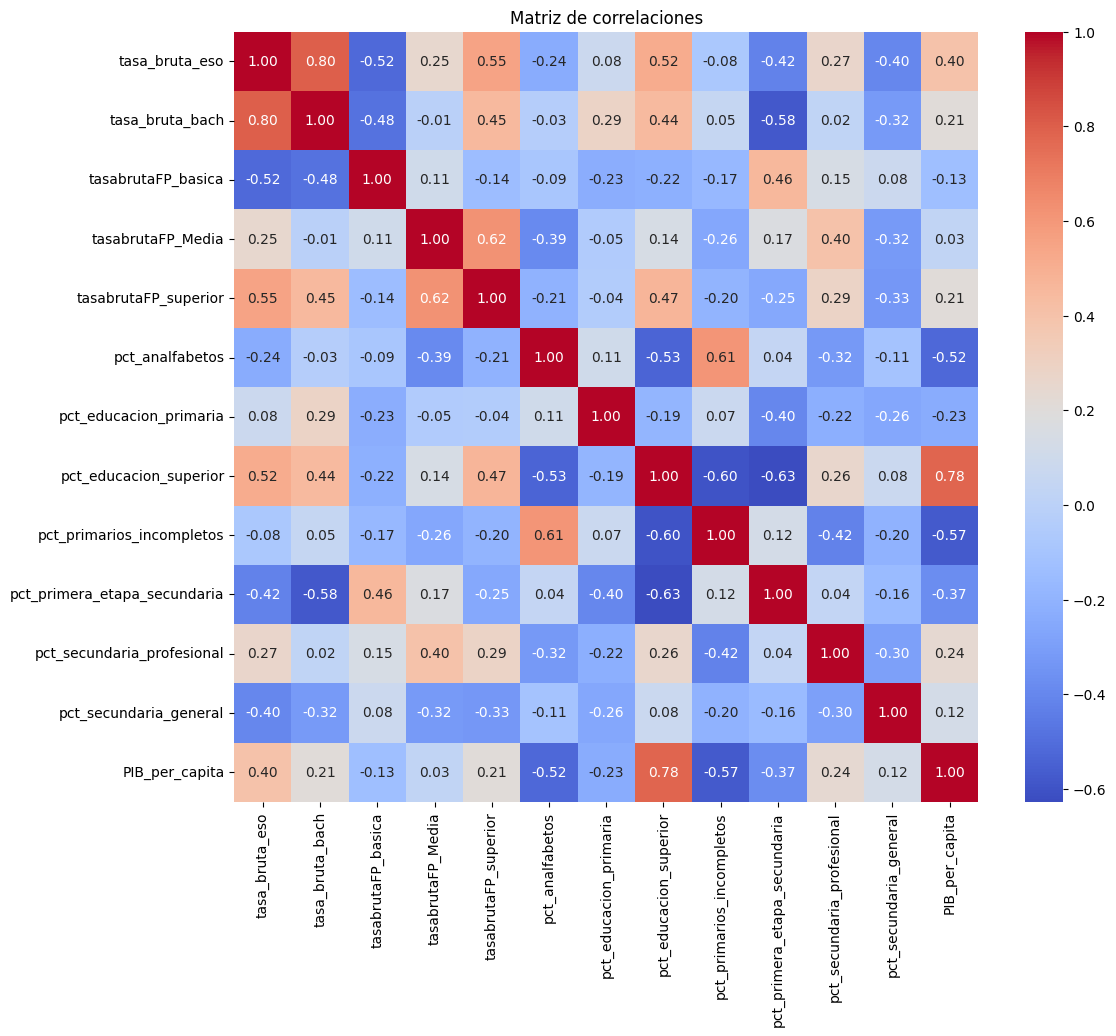

pct_analfabetos  pct_educacion_primaria  \
ccaa      year                                            
Andalucia 2014            2.625                  14.950   
          2014            4.850                  14.275   
          2015            2.225                  14.125   
          2015            4.775                  13.675   
          2016            1.925                  13.350   

                pct_educacion_superior  pct_primarios_incompletos  \
ccaa      year                                                      
Andalucia 2014                  21.125                      8.825   
          2014                  22.400                     10.875   
          2015                  21.675                      9.000   
          2015                  23.175                     10.800   
          2016                  22.325                      8.700   

                pct_primera_etapa_secundaria  pct_secundaria_profesional  \
ccaa      year                                                             
Andalucia 2014                        33.650                       6.950   
          2014                        28.675                       7.500   
          2015                        33.650                       6.975   
          2015                        28.225                       7.625   
          2016                        34.250                       7.075   

                pct_secundaria_general  PIB_per_capita    sexo  
ccaa      year                                                  
Andalucia 2014                  11.875         16600.0  hombre  
          2014                  11.350         16600.0   mujer  
          2015                  12.400         17458.0  hombre  
          2015                  11.775         17458.0   mujer  
          2016                  12.375         17865.0  hombre

Dimensiones de X_eso: (342, 9)


In [199]:
# Calculamos la matriz de correlación para poder seleccionar de manera fundamentada las variables explicativas. 

corr_matriz = BaseFinal1.corr(numeric_only=True)

# Visualizamos la matriz de correlaciones para que sea más fácil interpretarla

plt.figure(figsize=(12,10))
sns.heatmap(corr_matriz, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlaciones")
plt.show()

# Tras la matriz de correlación, podemos elegir que v.explicativas vamos a emplear que no generen multicolinealidad en el modelo. 
# Por ello, estas son las variables explicativas que hemos seleccionado para este primer modelo. 

X_eso = BaseFinal1[[
    "pct_analfabetos",
    "pct_educacion_primaria",
    "pct_educacion_superior",
    "pct_primarios_incompletos",
    "pct_primera_etapa_secundaria",
    "pct_secundaria_profesional",
    "pct_secundaria_general",
    "PIB_per_capita",
    "sexo"
]]

# Visualizamos las v.explicativas

display(X_eso.head())
print("Dimensiones de X_eso:", X_eso.shape)

## Tratamiento de la variable categórica 'Sexo'

In [200]:
# Transformamos sexo en variable dummy/binaria                            # hombre = 0, mujer = 1

X_eso["sexo_transformacion"] = X_eso["sexo"].map({"hombre": 0, "mujer": 1})

# Comprobamos que la transformación se ha hecho correctamente

display(X_eso[["sexo", "sexo_transformacion"]].head())

# Revisamos si hay nulos tras la transformación

print("Nulos en sexo_transformacion:", X_eso["sexo_transformacion"].isnull().sum())

# Eliminamos la columna original

X_eso = X_eso.drop(columns=["sexo"])

# Comprobamos el resultado final

display(X_eso.head())
print("Dimensiones de X_eso:", X_eso.shape)

sexo  sexo_transformacion
ccaa      year                             
Andalucia 2014  hombre                    0
          2014   mujer                    1
          2015  hombre                    0
          2015   mujer                    1
          2016  hombre                    0

Nulos en sexo_transformacion: 0


pct_analfabetos  pct_educacion_primaria  \
ccaa      year                                            
Andalucia 2014            2.625                  14.950   
          2014            4.850                  14.275   
          2015            2.225                  14.125   
          2015            4.775                  13.675   
          2016            1.925                  13.350   

                pct_educacion_superior  pct_primarios_incompletos  \
ccaa      year                                                      
Andalucia 2014                  21.125                      8.825   
          2014                  22.400                     10.875   
          2015                  21.675                      9.000   
          2015                  23.175                     10.800   
          2016                  22.325                      8.700   

                pct_primera_etapa_secundaria  pct_secundaria_profesional  \
ccaa      year                                                             
Andalucia 2014                        33.650                       6.950   
          2014                        28.675                       7.500   
          2015                        33.650                       6.975   
          2015                        28.225                       7.625   
          2016                        34.250                       7.075   

                pct_secundaria_general  PIB_per_capita  sexo_transformacion  
ccaa      year                                                               
Andalucia 2014                  11.875         16600.0                    0  
          2014                  11.350         16600.0                    1  
          2015                  12.400         17458.0                    0  
          2015                  11.775         17458.0                    1  
          2016                  12.375         17865.0                    0

Dimensiones de X_eso: (342, 9)


## Estudio del coeficiente VIF (Factor de la inflación de la varianza)

In [201]:
# Matriz solo con las variables explicativas del modelo 1.

X_vif_eso = X_eso.copy()

# Comprobamos si hay nulos
print("Nulos por columna:")
print(X_vif_eso.isnull().sum())

# Calculamos el facto de la inflación de la varianza (VIF).
# 1. Creamos una tabla vacía donde guardaremos los resultados.

vif_eso = pd.DataFrame()

# 2. Guardamos el nombre de cada variable.

vif_eso["Variable"] = X_vif_eso.columns

# 3. Calculamos el VIF de cada variable.

vif_eso["VIF"] = [
    variance_inflation_factor(X_vif_eso.values, i)
    for i in range(X_vif_eso.shape[1])
]

# Ordenamos de mayor a menor en función de los resultados del VIF.

vif_eso = vif_eso.sort_values("VIF", ascending=False)

# Mostramos resultados.

print("VIF - Modelo 1: Tasa bruta ESO")
display(vif_eso)

Nulos por columna:
pct_analfabetos                 0
pct_educacion_primaria          0
pct_educacion_superior          0
pct_primarios_incompletos       0
pct_primera_etapa_secundaria    0
pct_secundaria_profesional      0
pct_secundaria_general          0
PIB_per_capita                  0
sexo_transformacion             0
dtype: int64
VIF - Modelo 1: Tasa bruta ESO


,Variable,VIF
2,pct_educacion_superior,83.540103
7,PIB_per_capita,61.796733
4,pct_primera_etapa_secundaria,40.053495
5,pct_secundaria_profesional,37.955796
6,pct_secundaria_general,30.104624
1,pct_educacion_primaria,13.346058
3,pct_primarios_incompletos,7.707575
0,pct_analfabetos,4.467230
8,sexo_transformacion,3.657518


## Construcción final de la matriz del modelo 1

In [202]:
# Tras analizar el VIF quitamos las variables explicativas más correlacionadas.

X_eso = BaseFinal1[[
    "pct_educacion_superior",
    "PIB_per_capita",
    "sexo"
]].copy()

# Transformamos sexo en variable dummy/binaria                            # hombre = 0, mujer = 1

X_eso["sexo_transformacion"] = X_eso["sexo"].map({"hombre": 0, "mujer": 1})

# Revisamos si hay nulos tras la transformación

print("Nulos en sexo_transformacion:", X_eso["sexo_transformacion"].isnull().sum())

# Eliminamos la columna original

X_eso = X_eso.drop(columns=["sexo"])

# Comprobamos el resultado final

display(X_eso.head())
print("Dimensiones de X_eso:", X_eso.shape)

# Añadimos constante para el modelo econométrico porque va a recoger el nivel base de la v.dependiente cuando el resto de variables tomen valor 0.

X_eso_model = sm.add_constant(X_eso)

# Comprobamos dimensiones

print("Dimensiones de X_eso:", X_eso_model.shape)
print("Dimensiones de y_eso:", y_eso.shape)

# Visualizamos la estructura para ver que sea la correcta

display(X_eso_model.head())
display(y_eso.head())

Nulos en sexo_transformacion: 0


pct_educacion_superior  PIB_per_capita  sexo_transformacion
ccaa      year                                                             
Andalucia 2014                  21.125         16600.0                    0
          2014                  22.400         16600.0                    1
          2015                  21.675         17458.0                    0
          2015                  23.175         17458.0                    1
          2016                  22.325         17865.0                    0

Dimensiones de X_eso: (342, 3)
Dimensiones de X_eso: (342, 4)
Dimensiones de y_eso: (342,)


const  pct_educacion_superior  PIB_per_capita  \
ccaa      year                                                  
Andalucia 2014    1.0                  21.125         16600.0   
          2014    1.0                  22.400         16600.0   
          2015    1.0                  21.675         17458.0   
          2015    1.0                  23.175         17458.0   
          2016    1.0                  22.325         17865.0   

                sexo_transformacion  
ccaa      year                       
Andalucia 2014                    0  
          2014                    1  
          2015                    0  
          2015                    1  
          2016                    0

ccaa       year
Andalucia  2014    69.7
           2014    81.8
           2015    71.9
           2015    83.6
           2016    68.3
Name: tasa_bruta_eso, dtype: float64

## Estimación del modelo Mínimos Cuadrados Ordinarios Agrupados 'Pooled OLS'

In [203]:
# Estimamos el modelo Mínimos Cuadrados Ordinarios Agrupados (MCO)

MCO_model = PooledOLS(y_eso, X_eso_model)
MCO_results = MCO_model.fit()

# Obtenemos los resultados

print(MCO_results.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:         tasa_bruta_eso   R-squared:                        0.4924
Estimator:                  PooledOLS   R-squared (Between):              0.3629
No. Observations:                 342   R-squared (Within):               0.6572
Date:                Wed, Apr 08 2026   R-squared (Overall):              0.4924
Time:                        17:46:18   Log-likelihood                   -1127.2
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      109.30
Entities:                          19   P-value                           0.0000
Avg Obs:                       18.000   Distribution:                   F(3,338)
Min Obs:                       18.000                                           
Max Obs:                       18.000   F-statistic (robust):             109.30
                            

## Estimación del modelo de efectos fijos

In [204]:
# Estimamos el modelo de efectos fijos

EF_model = PanelOLS(y_eso, X_eso_model, entity_effects=True)
EF_results = EF_model.fit()

# Obtenemos los resultados

print(EF_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         tasa_bruta_eso   R-squared:                        0.6651
Estimator:                   PanelOLS   R-squared (Between):              0.3279
No. Observations:                 342   R-squared (Within):               0.6651
Date:                Wed, Apr 08 2026   R-squared (Overall):              0.4762
Time:                        17:46:18   Log-likelihood                   -915.74
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      211.79
Entities:                          19   P-value                           0.0000
Avg Obs:                       18.000   Distribution:                   F(3,320)
Min Obs:                       18.000                                           
Max Obs:                       18.000   F-statistic (robust):             211.79
                            

## Estimación del modelo de efectos aleatorios

In [205]:
# Estimación del modelo de efectos aleatorios

EA_model = RandomEffects(y_eso, X_eso_model)
EA_results = EA_model.fit()

# Obtenemos los resultados

print(EA_results.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:         tasa_bruta_eso   R-squared:                        0.6570
Estimator:              RandomEffects   R-squared (Between):              0.3339
No. Observations:                 342   R-squared (Within):               0.6650
Date:                Wed, Apr 08 2026   R-squared (Overall):              0.4796
Time:                        17:46:18   Log-likelihood                   -923.99
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      215.80
Entities:                          19   P-value                           0.0000
Avg Obs:                       18.000   Distribution:                   F(3,338)
Min Obs:                       18.000                                           
Max Obs:                       18.000   F-statistic (robust):             215.80
                            

## Test de Hausman: Elección entre efectos fijos y aleatorios

In [206]:
# Comprobamos que ambos modelos tienen los mismos coeficientes.

coeficientes_comunes = EF_results.params.index.intersection(EA_results.params.index)

# Extraemos los coeficientes estimados por ambos modelos para poder medir la distancia entre ellos. 

vector_FE = EF_results.params[coeficientes_comunes]
vector_RE = EA_results.params[coeficientes_comunes]

# Calculamos la diferencia enrre los coeficientes de cada modelo. 
# 1. Si la diferencia es pequeña quiere decir que los modelos se parecen.
# 2. Si la diferencia es grande quiere decir que los modelos no se parecen.

diferencia_coeficientes = vector_FE - vector_RE

# El test de Hausman considera la precisión con la que han sido estimados los coeficientes, para ello usa las matrices de covarianzas.

cov_FE = EF_results.cov.loc[coeficientes_comunes, coeficientes_comunes]
cov_RE = EA_results.cov.loc[coeficientes_comunes, coeficientes_comunes]

# Calculamos la diferencia entre ambas matrices de covarianza

diferencia_covarianza = cov_FE - cov_RE

# Calculamos el estadístico de Hausman, cuantifica si las diferencias observadas entre los coeficientes de ambos modelos son lo suficientemente grandes para rechazar el modelo de efectos aleatorios. 

cof_Hausman = float(diferencia_coeficientes.T @ np.linalg.inv(diferencia_covarianza) @ diferencia_coeficientes)

# Calculamos los grados de libertad. 

df = len(diferencia_coeficientes)

# Calculamos el p-valor

p_value = 1 - stats.chi2.cdf(cof_Hausman, df)

print("Estadístico de Hausman:", cof_Hausman)
print("Grados de libertad:", df)
print("p-valor:", p_value)

# Mostramos de manera más visual la decisión y los resultados obtenidos

hausman_resultados = pd.DataFrame({
    "Estadístico de Hausman": [round(cof_Hausman, 4)],
    "Grados de libertad": [df],
    "p-valor": [round(p_value, 4)],
    "Decisión": ["Rechazar H0" if p_value < 0.05 else "No rechazar H0"],
    "Modelo seleccionado": ["Efectos Fijos" if p_value < 0.05 else "Efectos Aleatorios"]
})

display(hausman_resultados)

Estadístico de Hausman: 0.7336107531100658
Grados de libertad: 4
p-valor: 0.9471202616474963


,Estadístico de Hausman,Grados de libertad,p-valor,Decisión,Modelo seleccionado
0,0.7336,4,0.9471,No rechazar H0,Efectos Aleatorios


## Estudio del coeficiente VIF tras hacer el modelo 1 (Factor de la inflación de la varianza)

In [207]:
# Para calcular el VIF usamos solo las variables explicativas.

X_vif_eso = X_eso.copy()

# Creamos una tabla vacía donde guardaremos los resultados.

vif_eso = pd.DataFrame()

# Guardamos y calculamos el coeficiente del VIF.

vif_eso["Variable"] = X_vif_eso.columns

vif_eso["VIF"] = [
    variance_inflation_factor(X_vif_eso.values, i)
    for i in range(X_vif_eso.shape[1])
]

# Mostramos los resultados obtenidos. 

print("VIF - Modelo 1: Tasa bruta ESO")
display(vif_eso.sort_values("VIF", ascending=False))

VIF - Modelo 1: Tasa bruta ESO


,Variable,VIF
0,pct_educacion_superior,58.525993
1,PIB_per_capita,55.575335
2,sexo_transformacion,2.049245


# **Modelo 2: Variable dependiente ÍNDICE DE ÉXITO ESCOLAR**

## Copia de la Base Final 1

In [208]:
# Creamos una copia de la Base Final 1 para no romper nada de lo anterior y trabajar de manera más limpia.

BaseFinal1copia = BaseFinal1.copy()

## Creación de la variable índice de éxito escolar

Estadísticos de ambas variables:


,tasa_bruta_eso,tasabrutaFP_basica
count,342.000000,342.000000
mean,78.454094,5.137500
std,9.184430,2.739401
min,46.600000,0.000000
25%,73.425000,3.200000
50%,80.200000,5.137500
75%,85.100000,6.900000
max,92.700000,13.800000


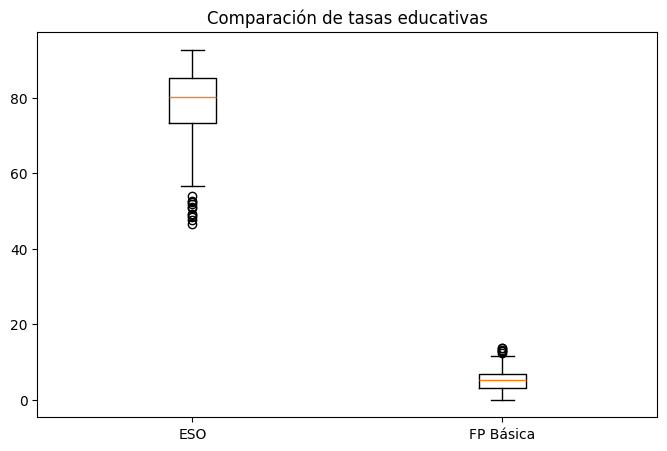

Estadísticos de la diferencia de ambas variables:


count    342.000000
mean      73.316594
std       10.854347
min       38.500000
25%       66.740625
50%       75.050000
75%       82.021875
max       90.200000
Name: diferencia_eso_fp, dtype: float64

tasa_bruta_eso  tasabrutaFP_basica  indice_exito_escolar
ccaa      year                                                          
Andalucia 2014            69.7              5.1375               56.7875
          2014            81.8              5.1375               66.4675
          2015            71.9              4.6000               58.4400
          2015            83.6              1.7000               67.2200
          2016            68.3              5.4000               55.7200

Estadísticos del índice de éxito escolar:


count    342.000000
mean      63.790775
std        7.080478
min       38.720000
25%       60.020000
50%       64.820000
75%       68.885000
max       74.960000
Name: indice_exito_escolar, dtype: float64

In [209]:
# Vamos a analizar ambas variables para tomar la decisión de cómo crear la variable índice de éxito escolar.
# 1. Obtenemos los estadísticos descriptivos de ambas variables

print("Estadísticos de ambas variables:")
display(BaseFinal1copia[["tasa_bruta_eso", "tasabrutaFP_basica"]].describe())

# 2. Visualizamos mediante boxplot ambas variables.

plt.figure(figsize=(8,5))
plt.boxplot([
    BaseFinal1copia["tasa_bruta_eso"],
    BaseFinal1copia["tasabrutaFP_basica"]
])
plt.xticks([1,2], ["ESO", "FP Básica"])
plt.title("Comparación de tasas educativas")
plt.show()

# 3. Calculamos las diferencias entre ambas variables.

print("Estadísticos de la diferencia de ambas variables:")
BaseFinal1copia["diferencia_eso_fp"] = (
    BaseFinal1copia["tasa_bruta_eso"] - BaseFinal1copia["tasabrutaFP_basica"]
)
display(BaseFinal1copia["diferencia_eso_fp"].describe())

# Tras estos resultados, observamos claramente que la variable 'tasa bruta ESO' presenta valores significativamente superiores a la variable 'tasa bruta FP Básica'. 
# Por ello, en lugar de hacer una simple media vamos a construir el índice empleando una media ponderada.
# Asignando mayor paso a la tasa bruta eso (80%) frente a FP Básica (20%).

# 1. Creamos el índice ponderado.

BaseFinal1copia["indice_exito_escolar"] = (
    0.8 * BaseFinal1copia["tasa_bruta_eso"] +
    0.2 * BaseFinal1copia["tasabrutaFP_basica"]
)

# 2. Comprobamos que la variable se ha creado correctamente.

display(
    BaseFinal1copia[[
        "tasa_bruta_eso",
        "tasabrutaFP_basica",
        "indice_exito_escolar"
    ]].head()
)

# 3. Obtenemos los estadísticos descriptivos de la nueva variable.

print("Estadísticos del índice de éxito escolar:")
display(BaseFinal1copia["indice_exito_escolar"].describe())

## Definición de la variable objetivo

In [210]:
# Definimos la variable dependiente del modelo, en este caso será 'TASA BRUTA ESO'

y_exito = BaseFinal1copia["indice_exito_escolar"]

# Visualizamos para comprobar que está correcto

print("Variable objetivo del modelo 2:")
display(y_exito.head())
print("Número de CCAA:", y_exito.index.get_level_values("ccaa").nunique())

Variable objetivo del modelo 2:


ccaa       year
Andalucia  2014    56.7875
           2014    66.4675
           2015    58.4400
           2015    67.2200
           2016    55.7200
Name: indice_exito_escolar, dtype: float64

Número de CCAA: 19


## Selección de las variables explicativas

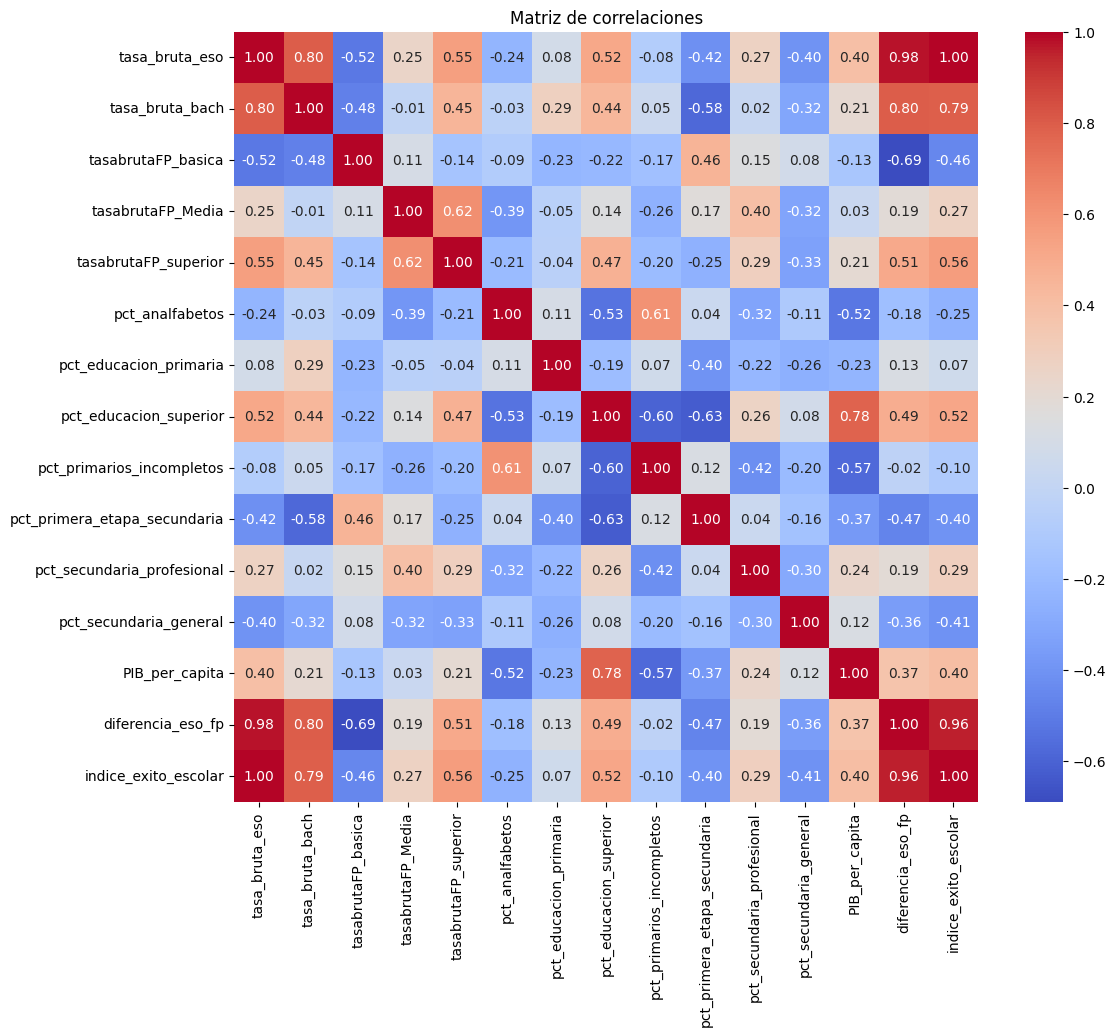

pct_analfabetos  pct_educacion_primaria  \
ccaa      year                                            
Andalucia 2014            2.625                  14.950   
          2014            4.850                  14.275   
          2015            2.225                  14.125   
          2015            4.775                  13.675   
          2016            1.925                  13.350   

                pct_educacion_superior  pct_primarios_incompletos  \
ccaa      year                                                      
Andalucia 2014                  21.125                      8.825   
          2014                  22.400                     10.875   
          2015                  21.675                      9.000   
          2015                  23.175                     10.800   
          2016                  22.325                      8.700   

                pct_secundaria_profesional  pct_secundaria_general  \
ccaa      year                                                       
Andalucia 2014                       6.950                  11.875   
          2014                       7.500                  11.350   
          2015                       6.975                  12.400   
          2015                       7.625                  11.775   
          2016                       7.075                  12.375   

                PIB_per_capita    sexo  
ccaa      year                          
Andalucia 2014         16600.0  hombre  
          2014         16600.0   mujer  
          2015         17458.0  hombre  
          2015         17458.0   mujer  
          2016         17865.0  hombre

Dimensiones de X_exito: (342, 8)


In [211]:
# Calculamos la matriz de correlación para poder seleccionar de manera fundamentada las variables explicativas. 

corr_matriz = BaseFinal1copia.corr(numeric_only=True)

# Visualizamos la matriz de correlaciones para que sea más fácil interpretarla

plt.figure(figsize=(12,10))
sns.heatmap(corr_matriz, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlaciones")
plt.show()

# Tras la matriz de correlación, podemos elegir que v.explicativas vamos a emplear que no generen multicolinealidad en el modelo. 
# Por ello, estas son las variables explicativas que hemos seleccionado para este primer modelo. 

X_exito = BaseFinal1copia[[
    "pct_analfabetos",
    "pct_educacion_primaria",
    "pct_educacion_superior",
    "pct_primarios_incompletos",
    "pct_secundaria_profesional",
    "pct_secundaria_general",
    "PIB_per_capita",
    "sexo"
]]

# Visualizamos las v.explicativas

display(X_exito.head())
print("Dimensiones de X_exito:", X_exito.shape)


In [212]:
# Una vez hecho esto elegidas las v.explicativas, tenemos que transformar la variable 'sexo'

X_exito = BaseFinal1copia[[
    "pct_analfabetos",
    "pct_educacion_primaria",
    "pct_educacion_superior",
    "pct_primarios_incompletos",
    "pct_primera_etapa_secundaria",
    "pct_secundaria_profesional",
    "pct_secundaria_general",
    "PIB_per_capita",
    "sexo"
]].copy()

## Tratamiento de la variable categórica 'Sexo'

In [213]:
# Transformamos sexo en variable dummy/binaria                            # hombre = 0, mujer = 1

X_exito["sexo_transformacion"] = X_exito["sexo"].map({"hombre": 0, "mujer": 1})

# Comprobamos que la transformación se ha hecho correctamente

display(X_exito[["sexo", "sexo_transformacion"]].head())

# Revisamos si hay nulos tras la transformación

print("Nulos en sexo_transformacion:", X_exito["sexo_transformacion"].isnull().sum())

# Eliminamos la columna original

X_exito = X_exito.drop(columns=["sexo"])

# Comprobamos el resultado final

display(X_exito.head())
print("Dimensiones de X_exito:", X_exito.shape)

sexo  sexo_transformacion
ccaa      year                             
Andalucia 2014  hombre                    0
          2014   mujer                    1
          2015  hombre                    0
          2015   mujer                    1
          2016  hombre                    0

Nulos en sexo_transformacion: 0


pct_analfabetos  pct_educacion_primaria  \
ccaa      year                                            
Andalucia 2014            2.625                  14.950   
          2014            4.850                  14.275   
          2015            2.225                  14.125   
          2015            4.775                  13.675   
          2016            1.925                  13.350   

                pct_educacion_superior  pct_primarios_incompletos  \
ccaa      year                                                      
Andalucia 2014                  21.125                      8.825   
          2014                  22.400                     10.875   
          2015                  21.675                      9.000   
          2015                  23.175                     10.800   
          2016                  22.325                      8.700   

                pct_primera_etapa_secundaria  pct_secundaria_profesional  \
ccaa      year                                                             
Andalucia 2014                        33.650                       6.950   
          2014                        28.675                       7.500   
          2015                        33.650                       6.975   
          2015                        28.225                       7.625   
          2016                        34.250                       7.075   

                pct_secundaria_general  PIB_per_capita  sexo_transformacion  
ccaa      year                                                               
Andalucia 2014                  11.875         16600.0                    0  
          2014                  11.350         16600.0                    1  
          2015                  12.400         17458.0                    0  
          2015                  11.775         17458.0                    1  
          2016                  12.375         17865.0                    0

Dimensiones de X_exito: (342, 9)


## Estudio del coeficiente VIF (Factor de la inflación de la varianza)

In [214]:
# Para calcular el VIF usamos solo las variables explicativas y no añadimos todavía la constante.

X_vif_exito = X_exito.copy()

# Creamos una tabla vacía donde vamos a almacenar los resultados.

vif_exito = pd.DataFrame()

# Guardamos el nombre de cada variable.

vif_exito["Variable"] = X_vif_exito.columns

# Calculamos el VIF de cada variable.

vif_exito["VIF"] = [
    variance_inflation_factor(X_vif_exito.values, i)
    for i in range(X_vif_exito.shape[1])
]

# Ordenamos los resultados de mayor a menor VIF

vif_exito = vif_exito.sort_values("VIF", ascending=False)

# Mostramos los resultados obtenidos. 

print("VIF - Modelo índice de éxito escolar")
display(vif_exito.sort_values("VIF", ascending=False))

VIF - Modelo índice de éxito escolar


,Variable,VIF
2,pct_educacion_superior,83.540103
7,PIB_per_capita,61.796733
4,pct_primera_etapa_secundaria,40.053495
5,pct_secundaria_profesional,37.955796
6,pct_secundaria_general,30.104624
1,pct_educacion_primaria,13.346058
3,pct_primarios_incompletos,7.707575
0,pct_analfabetos,4.467230
8,sexo_transformacion,3.657518


## Construcción final de la matriz del modelo 2

In [215]:
# Tras analizar el VIF quitamos las variables explicativas más correlacionadas.

X_exito = BaseFinal1copia[[
    "pct_educacion_superior",
    "PIB_per_capita",
    "sexo"
]].copy()

# Transformamos sexo en variable dummy/binaria                            # hombre = 0, mujer = 1

X_exito["sexo_transformacion"] = X_exito["sexo"].map({"hombre": 0, "mujer": 1})

# Revisamos si hay nulos tras la transformación

print("Nulos en sexo_transformacion:", X_exito["sexo_transformacion"].isnull().sum())

# Eliminamos la columna original

X_exito = X_exito.drop(columns=["sexo"])

# Comprobamos el resultado final

display(X_exito.head())
print("Dimensiones de X_exito:", X_exito.shape)

# Añadimos constante para el modelo econométrico porque va a recoger el nivel base de la v.dependiente cuando el resto de variables tomen valor 0.

X_exito_model = sm.add_constant(X_exito)

# Comprobamos dimensiones.

print("Dimensiones de X_exito_model:", X_exito_model.shape)
print("Dimensiones de y_exito:", y_exito.shape)

# Visualizamos la estructura para ver que sea la correcta.

display(X_exito_model.head())
display(y_exito.head())


Nulos en sexo_transformacion: 0


pct_educacion_superior  PIB_per_capita  sexo_transformacion
ccaa      year                                                             
Andalucia 2014                  21.125         16600.0                    0
          2014                  22.400         16600.0                    1
          2015                  21.675         17458.0                    0
          2015                  23.175         17458.0                    1
          2016                  22.325         17865.0                    0

Dimensiones de X_exito: (342, 3)
Dimensiones de X_exito_model: (342, 4)
Dimensiones de y_exito: (342,)


const  pct_educacion_superior  PIB_per_capita  \
ccaa      year                                                  
Andalucia 2014    1.0                  21.125         16600.0   
          2014    1.0                  22.400         16600.0   
          2015    1.0                  21.675         17458.0   
          2015    1.0                  23.175         17458.0   
          2016    1.0                  22.325         17865.0   

                sexo_transformacion  
ccaa      year                       
Andalucia 2014                    0  
          2014                    1  
          2015                    0  
          2015                    1  
          2016                    0

ccaa       year
Andalucia  2014    56.7875
           2014    66.4675
           2015    58.4400
           2015    67.2200
           2016    55.7200
Name: indice_exito_escolar, dtype: float64

## Estimación del modelo Mínimos Cuadrados Ordinarios Agrupados 'Pooled OLS'

In [216]:
# Estimamos el modelo Mínimos Cuadrados Ordinarios Agrupados (MCO).

MCO_exito_model = PooledOLS(y_exito, X_exito_model)
MCO_exito_results = MCO_exito_model.fit()

# Obtenemos los resultados

print(MCO_exito_results.summary)

                           PooledOLS Estimation Summary                           
Dep. Variable:     indice_exito_escolar   R-squared:                        0.4723
Estimator:                    PooledOLS   R-squared (Between):              0.3646
No. Observations:                   342   R-squared (Within):               0.6128
Date:                  Wed, Apr 08 2026   R-squared (Overall):              0.4723
Time:                          17:46:20   Log-likelihood                   -1044.9
Cov. Estimator:              Unadjusted                                           
                                          F-statistic:                      100.85
Entities:                            19   P-value                           0.0000
Avg Obs:                         18.000   Distribution:                   F(3,338)
Min Obs:                         18.000                                           
Max Obs:                         18.000   F-statistic (robust):             100.85
    

## Estimación del modelo de efectos fijos

In [217]:
# Estimamos el modelo de efectos fijos.

EF_exito_model = PanelOLS(y_exito, X_exito_model, entity_effects=True)
EF_exito_results = EF_exito_model.fit()

# Obtenemos los resultados

print(EF_exito_results.summary)


                           PanelOLS Estimation Summary                            
Dep. Variable:     indice_exito_escolar   R-squared:                        0.6204
Estimator:                     PanelOLS   R-squared (Between):              0.3356
No. Observations:                   342   R-squared (Within):               0.6204
Date:                  Wed, Apr 08 2026   R-squared (Overall):              0.4592
Time:                          17:46:20   Log-likelihood                   -845.84
Cov. Estimator:              Unadjusted                                           
                                          F-statistic:                      174.32
Entities:                            19   P-value                           0.0000
Avg Obs:                         18.000   Distribution:                   F(3,320)
Min Obs:                         18.000                                           
Max Obs:                         18.000   F-statistic (robust):             174.32
    

## Estimación del modelo de efectos aleatorios

In [218]:
# Estimación del modelo de efectos aleatorios

EA_exito_model = RandomEffects(y_exito, X_exito_model)
EA_exito_results = EA_exito_model.fit()

# Obtenemos los resultados

print(EA_exito_results.summary)


                         RandomEffects Estimation Summary                         
Dep. Variable:     indice_exito_escolar   R-squared:                        0.6127
Estimator:                RandomEffects   R-squared (Between):              0.3402
No. Observations:                   342   R-squared (Within):               0.6203
Date:                  Wed, Apr 08 2026   R-squared (Overall):              0.4618
Time:                          17:46:20   Log-likelihood                   -854.02
Cov. Estimator:              Unadjusted                                           
                                          F-statistic:                      178.21
Entities:                            19   P-value                           0.0000
Avg Obs:                         18.000   Distribution:                   F(3,338)
Min Obs:                         18.000                                           
Max Obs:                         18.000   F-statistic (robust):             178.21
    

## Test de Hausman: Elección entre efectos fijos y aleatorios

In [219]:
# Seleccionamos los coeficientes comunes en ambos modelos.

coeficientes_comunes = EF_exito_results.params.index.intersection(EA_exito_results.params.index)

# Extraemos los coeficientes estimados por ambos modelos.

vector_FE = EF_exito_results.params[coeficientes_comunes]
vector_RE = EA_exito_results.params[coeficientes_comunes]

# Calculamos la diferencia enrre los coeficientes de cada modelo. 
# 1. Si la diferencia es pequeña quiere decir que los modelos se parecen.
# 2. Si la diferencia es grande quiere decir que los modelos no se parecen.

diferencia_coeficientes = vector_FE - vector_RE

# Extraemos las matrices de covarianza.

cov_FE = EF_exito_results.cov.loc[coeficientes_comunes, coeficientes_comunes]
cov_RE = EA_exito_results.cov.loc[coeficientes_comunes, coeficientes_comunes]

# Diferencia entre matrices de covarianza.

diferencia_covarianza = cov_FE - cov_RE

# Calculamos el estadístico de Hausman, cuantifica si las diferencias observadas entre los coeficientes de ambos modelos son lo suficientemente grandes para rechazar el modelo de efectos aleatorios. 

coef_Hausman = float(
    diferencia_coeficientes.T @ np.linalg.inv(diferencia_covarianza) @ diferencia_coeficientes
)

# Grados de libertad.

df = len(diferencia_coeficientes)

# p-valor.

p_value = 1 - stats.chi2.cdf(coef_Hausman, df)

# Mostramos de manera más visual la decisión y los resultados obtenidos.

hausman_resultados_exito = pd.DataFrame({
    "Estadístico de Hausman": [round(coef_Hausman, 4)],
    "Grados de libertad": [df],
    "p-valor": [round(p_value, 4)],
    "Decisión": ["Rechazar H0" if p_value < 0.05 else "No rechazar H0"],
    "Modelo seleccionado": ["Efectos Fijos" if p_value < 0.05 else "Efectos Aleatorios"]
})

display(hausman_resultados_exito)

,Estadístico de Hausman,Grados de libertad,p-valor,Decisión,Modelo seleccionado
0,0.618,4,0.961,No rechazar H0,Efectos Aleatorios


## Estudio del coeficiente VIF tras hacer el modelo 2 (Factor de la inflación de la varianza)

In [221]:
# Para calcular el VIF usamos solo las variables explicativas.

X_vif_exito = X_exito.copy()

# Creamos una tabla vacía donde guardaremos los resultados.

vif_exito = pd.DataFrame()

# Guardamos y calculamos el coeficiente del VIF.

vif_exito["Variable"] = X_vif_exito.columns

vif_exito["VIF"] = [
    variance_inflation_factor(X_vif_exito.values, i)
    for i in range(X_vif_exito.shape[1])
]

# Mostramos los resultados obtenidos. 

print("VIF - Modelo 2: Índice del éxito escolar")
display(vif_exito.sort_values("VIF", ascending=False))

VIF - Modelo 2: Índice del éxito escolar


,Variable,VIF
0,pct_educacion_superior,58.525993
1,PIB_per_capita,55.575335
2,sexo_transformacion,2.049245


# **Comparación del modelo 1 y el modelo 2**

In [222]:
# Mostramos los coeficientes de ambos modelos para poderlos analizar de forma más sencilla. 

coef_modelo_1 = pd.DataFrame({
    "Variable": EF_results.params.index,
    "Coeficiente_Modelo_1": EF_results.params.values,
    "Pvalor_Modelo_1": EF_results.pvalues.values
})

coef_modelo_2 = pd.DataFrame({
    "Variable": EA_exito_results.params.index,
    "Coeficiente_Modelo_2": EA_exito_results.params.values,
    "Pvalor_Modelo_2": EA_exito_results.pvalues.values
})

comparacion_coeficientes = coef_modelo_1.merge(coef_modelo_2, on="Variable", how="outer")

print("RESUMEN COMPARATIVO DE LOS COEFICIENTES DE LOS MODELOS ECONOMÉTRICOS:")
display(comparacion_coeficientes)

# Mostramos un breve resumen de los modelos con las conclusiones e indicadores más importantes. 

resumen_final_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo 1: Tasa bruta ESO",
        "Modelo 2: Índice de éxito escolar"
    ],
    "Modelo seleccionado": [
        "Efectos Aleatorios",
        "Efectos Aleatorios"
    ],
    "Hausman p-valor": [
        0.9471,
        0.961
    ],
    "R² modelo principal": [
        round(EF_results.rsquared, 4),
        round(EA_exito_results.rsquared, 4)
    ],
    "Modelo alternativo descartado": [
        "Efectos Fijos",
        "Efectos Fijos"
    ]
})

print("RESUMEN COMPARATIVO DE LOS MODELOS ECONOMÉTRICOS:")
display(resumen_final_modelos)

RESUMEN COMPARATIVO DE LOS COEFICIENTES DE LOS MODELOS ECONOMÉTRICOS:


,Variable,Coeficiente_Modelo_1,Pvalor_Modelo_1,Coeficiente_Modelo_2,Pvalor_Modelo_2
0,PIB_per_capita,0.000261,0.030786,0.000233,0.013141
1,const,57.062821,0.000000,46.055923,0.000000
2,pct_educacion_superior,0.363536,0.000325,0.303279,0.000152
3,sexo_transformacion,9.208475,0.000000,6.721628,0.000000


RESUMEN COMPARATIVO DE LOS MODELOS ECONOMÉTRICOS:


,Modelo,Modelo seleccionado,Hausman p-valor,R² modelo principal,Modelo alternativo descartado
0,Modelo 1: Tasa bruta ESO,Efectos Aleatorios,0.9471,0.6651,Efectos Fijos
1,Modelo 2: Índice de éxito escolar,Efectos Aleatorios,0.9610,0.6127,Efectos Fijos
